# Exploratory Data Analysis (EDA) - Netflix Prize Dataset
This notebook performs an in-depth empirical exploration of our optimized Parquet datasets to uncover user activity behavior, item distributions, data sparsity boundaries, and temporal patterns.

In [6]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

CURRENT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
BASE_DIR = CURRENT_DIR if os.path.basename(CURRENT_DIR) == "data" else os.path.join(CURRENT_DIR, "data")
TRAIN_PATH = os.path.join(BASE_DIR, "df_train.parquet")
MOVIES_PATH = os.path.join(BASE_DIR, "df_movies.parquet")

df = pd.read_parquet(TRAIN_PATH, engine='fastparquet')
df_movies = pd.read_parquet(MOVIES_PATH, engine='fastparquet')
print(f"[*] Dataset loaded. Total Rows: {len(df):,}")

[*] Dataset loaded. Total Rows: 99,072,112


In [7]:
n_users = df['User_ID'].nunique()
n_items = df['Movie_ID'].nunique()
n_ratings = len(df)

possible_ratings = n_users * n_items
sparsity = (1 - (n_ratings / possible_ratings)) * 100

print(f"Total Unique Users: {n_users:,}")
print(f"Total Unique Movies: {n_items:,}")
print(f"Matrix Sparsity: {sparsity:.4f}%")

Total Unique Users: 480,189
Total Unique Movies: 17,770
Matrix Sparsity: 98.8389%


###  Data Sparsity Evaluation & Strategic Impact

* **Technical Implications:** With a matrix sparsity exceeding **98.8%**, standard neighborhood-based collaborative filtering (like calculating raw item-to-item Cosine Similarity) is computationally non-viable. The massive volume of empty cells creates a high-dimensional vector space where common items are rare, resulting in unstable similarity scores. This mathematically justifies our decision to transition to **Matrix Factorization (SVD / Truncated SVD)** or deep-learning-based embeddings, which compress this sparse space into dense, lower-dimensional vectors.
* **Business Implications:** The intense sparsity underscores the "Long Tail" reality of the media catalog. While a few dozen blockbuster hits capture the majority of user attention, thousands of niche titles sit completely unobserved by the average subscriber. The true revenue engine of a recommendation system lies in successfully activating this long tail—matching hidden gems to hyper-specific user tastes, thereby boosting catalog utilization and increasing subscriber retention.


Rating 1⭐: 4.59%
Rating 2⭐: 10.09%
Rating 3⭐: 28.73%
Rating 4⭐: 33.60%
Rating 5⭐: 23.00%


C:\Users\LOQ\AppData\Local\Temp\ipykernel_12840\2907277167.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")


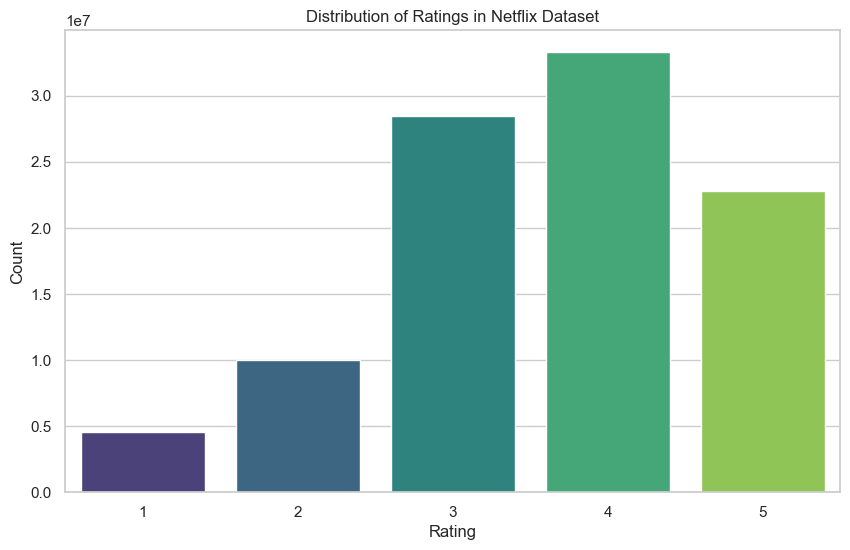

In [8]:
rating_counts = df['Rating'].value_counts().sort_index()
rating_pct = df['Rating'].value_counts(normalize=True).sort_index() * 100

for rating, pct in rating_pct.items():
    print(f"Rating {rating}⭐: {pct:.2f}%")

sns.barplot(x=rating_counts.index, y=rating_counts.values, palette="viridis")
plt.title("Distribution of Ratings in Netflix Dataset")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

### Rating Distribution Analysis & Bias Identification

* **Technical Implications:** The data shows a massive **positivity skew**, with 4 and 5-star ratings dominating the distribution, while 1-star reviews represent a microscopic fraction. This confirms a heavy *selection bias*—users naturally choose to watch content they already suspect they will enjoy. If a baseline model blindly predicts a 4-star rating across the board, it will return a deceptively low Root Mean Squared Error (RMSE). To build a robust model, we must center our data around user-specific rating means to account for individual user leniency or harshness.
* **Business Implications:** Users do not view ratings through a strict, objective scale. For most users, a 3-star rating represents a disappointment, 4-star is a baseline positive experience, and 5-star indicates high enthusiasm. Our recommendation system must focus heavily on predicting that top tier—the 5-star experiences—since surfacing content that users simply "don't mind" (4 stars) leads to homepage fatigue and churn, whereas uncovering true affinity items keeps users locked into the platform ecosystem.

Average ratings per user: 206.3
Median ratings per user: 93.0


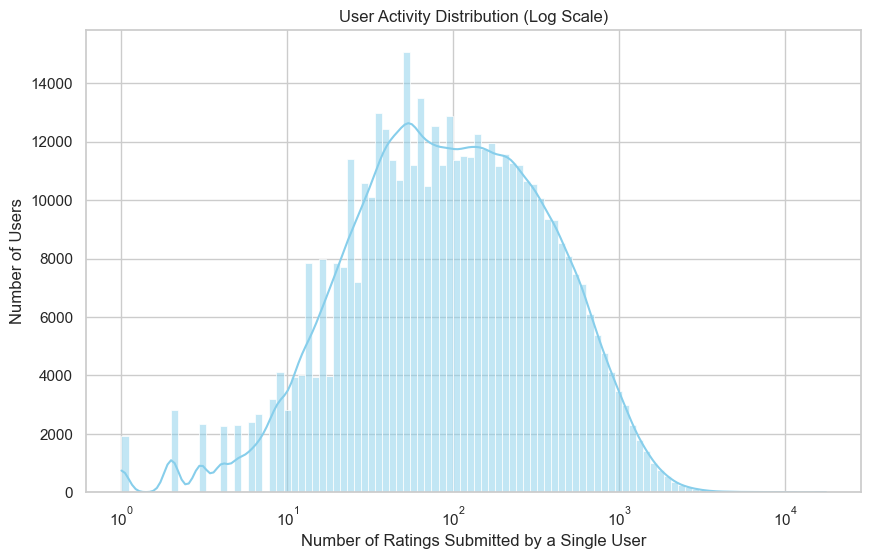

In [9]:
user_counts = df['User_ID'].value_counts()
print(f"Average ratings per user: {user_counts.mean():.1f}")
print(f"Median ratings per user: {user_counts.median():.1f}")

sns.histplot(user_counts, bins=100, kde=True, log_scale=True, color="skyblue")
plt.title("User Activity Distribution (Log Scale)")
plt.xlabel("Number of Ratings Submitted by a Single User")
plt.ylabel("Number of Users")
plt.show()

### User Engagement Profiles & The Cold-Start Constraint

* **Technical Implications:** User interaction volume follows a stark **Power Law (Pareto Principle)**. A tiny tier of super-users contributes thousands of data points, while a long tail of casual users has fewer than a dozen ratings total. This introduces the classic **User Cold-Start Problem**. Our collaborative filtering algorithms will perform exceptionally well on the power-users but will struggle with low-activity accounts. We must establish a threshold fallback strategy (such as content-based or popularity-anchored recommendations) for users with shallow behavioral profiles.
* **Business Implications:** Power-users provide high-volume data training metrics for free, but casual users represent the highest risk group for subscriber churn. Maximizing platform stickiness depends on nailing the user experience during their first handful of ratings. The business logic must ensure that a casual user's homepage shifts dynamically after even a single new rating interaction, ensuring they immediately feel the product adjusting to their presence.

In [10]:
movie_stats = df.groupby('Movie_ID').agg(
    rating_count=('Rating', 'count'),
    average_rating=('Rating', 'mean')
).reset_index()

movie_stats = movie_stats.merge(df_movies, on='Movie_ID', how='left')

print("🔥 Top 5 Most Popular Movies:")
print(movie_stats.sort_values(by='rating_count', ascending=False)[['Title', 'rating_count', 'average_rating']].head(5).to_string(index=False))

print("\n💎 Top 5 Highest Rated Movies (Min 10k reviews):")
print(movie_stats[movie_stats['rating_count'] >= 10000].sort_values(by='average_rating', ascending=False)[['Title', 'rating_count', 'average_rating']].head(5).to_string(index=False))

🔥 Top 5 Most Popular Movies:
                 Title  rating_count  average_rating
     Miss Congeniality        227715        3.359230
      Independence Day        216233        3.723964
           The Patriot        200490        3.783451
The Day After Tomorrow        194695        3.442564
          Pretty Woman        190320        3.901361

💎 Top 5 Highest Rated Movies (Min 10k reviews):
                                                              Title  rating_count  average_rating
        Lord of the Rings: The Return of the King: Extended Edition         72600        4.722741
The Lord of the Rings: The Fellowship of the Ring: Extended Edition         72274        4.716316
                Lord of the Rings: The Two Towers: Extended Edition         73630        4.701738
                          The Shawshank Redemption: Special Edition        137812        4.593091
                          Lord of the Rings: The Return of the King        133597        4.545529


### Catalog Dynamics: Hit-Driven Popularity vs. Niche Quality

* **Technical Implications:** The data exhibits a heavy structural bias toward iconic mainstream hits (e.g., *Miss Congeniality*). Additionally, looking at raw averages without constraints creates statistical anomalies, where obscure films with a single 5-star review artificially rank as the platform's "best" movies. By applying a **minimum filter threshold of 10,000 reviews**, we normalize the quality metric. When we move to the modeling phase, we must use regularized scoring (shrinkage parameters) to penalize high predicted ratings backed by low historical volumes.
* **Business Implications:** This distribution forms the core balancing act of product design. If our recommendation module only surfaces top-tier popular hits, the user interface feels repetitive and unimaginative. Conversely, if it only serves hyper-niche, highly-rated obscure content, users lose contextual trust. The production recommendation engine must achieve a hybrid equilibrium—using blockbuster anchors to establish baseline familiarity while weaving in personalized niche discoveries to create "serendipity."